# Interactive Denoising Lab — PandaOmron + GRPO LoRA — all 4 pool scenes, full_pool4_v7 PAWS `iter_0009` (v5.5)

v5's seed sweep for the **base model (no LoRA)** and one checkpoint, run on the first
observation of **each of the 4 pool scenes** (100067, 101067, 102067, 103067):

`grpo_data/full_pool4_v7/lr5e-5_plam0.4_…_postreopen1_res5_PAWS1.5/iter_0009`

CoffeeServeMug, `apply_jitter_fix` on, `jitter_pos 0.4`, PAWS target ratio 1.5 (max 5),
branched from `…_postreopen1/iter_0005`. The pool is `100067 + j·1000` for j = 0–3, and
fast-forward was off (`fast_forward_pct 0.0`), so each observation is exactly where that
scene's training rollouts started. The no-PAWS control's `iter_0009` (same parent) is
commented out in `CHECKPOINTS`; uncomment it to add a third run to every scene.

Per scene and run, the printout and the composite figure are v5's: spread stats, jerk /
smoothness stats, 3D panel + X/Y/Z traces + mean ± std. The **cross-scene summary** at the
end puts the four scenes side by side and adds v4.5's direct leak measure (`abs leak`,
`noise corr`). Scene 103067 is v5's observation, so its BASE row should reproduce v5's
(`pathjerk` 0.226).

How it works (v5 has the details):
- **Observations** are rebuilt from each seed in the robocasa venv (Cell 1.5 runs
  `capture_seed_obs.py`, cached in `OBS_DIR`). `EXPECTED_SCENES` holds each seed's `scene:`
  fingerprint from the pool4 eval logs, so a scene that rebuilds differently raises instead
  of being analyzed.
- **One model load.** LoRA is injected once (rank 16, alpha 32, not merged) and each
  checkpoint is swapped in with `load_lora_checkpoint`, which checks keys and shapes strictly.
  BASE runs with the adapters disabled.
- **Backbone features are encoded once per scene**, since LoRA only touches the DiT.
- **Noise seed `s` starts every run from the same initial noise**, so trajectories pair up
  by seed across runs.

To re-run one scene: `analyze_all_checkpoints(OBS_PATHS[100067])`.


In [1]:
# Cell 1: Imports + config
import sys, os, json
import numpy as np
import torch
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from scripts.denoising_lab.denoising_lab import DenoisingLab, TrajectoryVisualizer

MODEL_PATH = "nvidia/GR00T-N1.6-3B"
EMBODIMENT_TAG = "robocasa_panda_omron"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Scenes: this run's 4-seed pool (scene_seed_pool_base 100067 + j*1000), each rebuilt
# in the robocasa venv by Cell 1.5 (no saved .npz).
ENV_NAME = "robocasa_panda_omron/CoffeeServeMug_PandaOmron_Env"
SEEDS = [100067, 101067, 102067, 103067]
SIM_PYTHON = os.path.join(REPO_ROOT, "gr00t/eval/sim/robocasa/robocasa_uv/.venv/bin/python")
OBS_DIR = "/tmp/denoising_lab_seed_obs"   # capture cache; force=True in Cell 1.5 rebuilds
# Each seed's "scene:" line from the pool4 eval logs (same collector path as training).
# Cell 1.5 raises if a rebuilt scene differs; set an entry to None to skip its check.
EXPECTED_SCENES = {
    100067: "layout=7 style=10 xml=272eec14 state=2b0f39fb",
    101067: "layout=7 style=10 xml=69b3bdf8 state=8d9ec5ae",
    102067: "layout=4 style=4 xml=eebccd49 state=86b3cdf8",
    103067: "layout=6 style=9 xml=f9a0812c state=58e81df8",
}

EEF_KEY = "end_effector_position"
N_SEEDS = 100              # noise seeds per run (matches v1 Cell 11)

# LoRA config — MUST match what the checkpoints were trained with.
# (This run's TB config table: lora_rank 16, lora_alpha 32, lora_dropout 0.0.)
LORA_RANK = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.0

# Also sweep the BASE model (no LoRA) by disabling the injected adapter. Produces the
# same composite figure and a row in the cross-scene summary. See Cell 4.
INCLUDE_BASE_MODEL = True

# Every figure's data is also saved to PLOT_DATA_DIR/<name>.npz so the plots can be
# re-drawn (e.g. smoothed) offline without the GPU. File list: "Saved plot data" below.
PLOT_DATA_DIR = os.path.join(REPO_ROOT, "scripts", "denoising_lab", "notebooks", "plot_data_v5.5")
os.makedirs(PLOT_DATA_DIR, exist_ok=True)


def save_plot_data(name, meta, **arrays):
    """Write arrays + a JSON meta string to PLOT_DATA_DIR/<name>.npz (loads without pickle)."""
    path = os.path.join(PLOT_DATA_DIR, f"{name}.npz")
    np.savez(path, meta_json=json.dumps(meta), **{k: np.asarray(v) for k, v in arrays.items()})
    print(f"Plot data saved: {path}")

# Checkpoints to compare: {short label: dir relative to REPO_ROOT holding lora_weights.pt}.
# The short label names the figures and summary rows; the full run name overflows them.
_V7 = "grpo_data/full_pool4_v7/lr5e-5_plam0.4_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD0.9_3epoch_gs12_ng4_mb128_IAG0.3_postreopen1"
CHECKPOINTS = {
    "PAWS1.5 it09": f"{_V7}_res5_PAWS1.5/iter_0009/",
    # No-PAWS control from the same parent (iter_0005); uncomment to add it to every scene.
    # "control it09": f"{_V7}/iter_0009/",
}

n_runs = len(CHECKPOINTS) + (1 if INCLUDE_BASE_MODEL else 0)
print(f"Device: {DEVICE}")
print(f"{len(SEEDS)} scenes x ({len(CHECKPOINTS)} checkpoints"
      f"{' + base model' if INCLUDE_BASE_MODEL else ''}) = {len(SEEDS) * n_runs} runs, {N_SEEDS} seeds each")
print(f"Plot data -> {PLOT_DATA_DIR}")


/home/ubuntu/my_Isaac-GR00T/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
4 scenes x (1 checkpoints + base model) = 8 runs, 100 seeds each
Plot data -> /home/ubuntu/my_Isaac-GR00T/scripts/denoising_lab/notebooks/plot_data_v5.5


### Saved plot data

Every figure's data is written to `PLOT_DATA_DIR` (`scripts/denoising_lab/notebooks/plot_data_v5.5/`),
one `.npz` per figure family and scene, so the plots can be re-drawn (e.g. smoothed) offline
without the GPU. `<obs>` is the observation file stem, e.g. `CoffeeServeMug_seed100067_step000`.

| file | figures |
|---|---|
| `camera_views__<obs>.npz` | camera views (saved because the observation itself is only a `/tmp` cache) |
| `seed_spread__<obs>.npz` | composite seed-spread figure per run (3D panel, X/Y/Z traces, mean±std) |

The cross-scene summary (tables + figure) is computed from the four `seed_spread` files, so it
has no file of its own and re-runs offline. Besides v5's arrays, `seed_spread` files hold
`act_norm` and `noise` (run, seed, step, xyz): each seed's raw normalized EEF action and its
initial noise, which `abs leak` needs. Each file holds a `meta_json` string with the
observation path, task, seed + scene fingerprint (`step_info`), checkpoint paths and array
shapes.

```python
d = np.load(os.path.join(PLOT_DATA_DIR, "seed_spread__CoffeeServeMug_seed100067_step000.npz"))
meta = json.loads(d["meta_json"].item())
d["all_pos"].shape   # (run, seed, timestep, xyz)
```


In [2]:
# Cell 1.5: Rebuild each pool scene in the robocasa venv and save its first observation.
# Runs capture_seed_obs.py there as a subprocess (robocasa isn't importable in this
# venv). Cached in OBS_DIR; force=True rebuilds.
import json
import subprocess

CAPTURE_SCRIPT = os.path.join(REPO_ROOT, "scripts/denoising_lab/eval/capture_seed_obs.py")


def capture_seed_observation(seed, env_name=ENV_NAME, force=False, expected_scene=None):
    task = env_name.split("/")[-1].removesuffix("_PandaOmron_Env")
    out = os.path.join(OBS_DIR, f"{task}_seed{seed}_step000.npz")
    if force or not os.path.exists(out):
        if not os.path.exists(SIM_PYTHON):
            raise FileNotFoundError(f"robocasa venv not found: {SIM_PYTHON} "
                                    "(see gr00t/eval/sim/robocasa/setup_RoboCasa.sh)")
        cmd = [SIM_PYTHON, "-u", CAPTURE_SCRIPT, "--env-name", env_name,
               "--seed", str(seed), "--out", out]
        proc = subprocess.Popen(cmd, cwd=REPO_ROOT, text=True, stdout=subprocess.PIPE,
                                stderr=subprocess.STDOUT,
                                env={**os.environ, "GRPO_CLEAN_OUTPUT": "1"})
        for line in proc.stdout:
            print("  [sim]", line, end="")
        if proc.wait() != 0:
            raise RuntimeError(f"capture_seed_obs.py exited {proc.returncode}; "
                               "see the [sim] lines above")
    with np.load(out, allow_pickle=True) as z:
        scene = json.loads(str(z["__step_info__"]))["scene_fingerprint"]
    print(f"seed {seed}: {out}\n  scene: {scene}")
    if expected_scene is not None and scene != expected_scene:
        raise RuntimeError(f"seed {seed} rebuilt a different scene than training:\n"
                           f"  got      {scene}\n  expected {expected_scene}")
    return out


OBS_PATHS = {s: capture_seed_observation(s, expected_scene=EXPECTED_SCENES.get(s)) for s in SEEDS}


  [sim] seed 100067 scene: layout=7 style=10 xml=272eec14 state=2b0f39fb
  [sim] saved /tmp/denoising_lab_seed_obs/CoffeeServeMug_seed100067_step000.npz


seed 100067: /tmp/denoising_lab_seed_obs/CoffeeServeMug_seed100067_step000.npz
  scene: layout=7 style=10 xml=272eec14 state=2b0f39fb


  [sim] seed 101067 scene: layout=7 style=10 xml=69b3bdf8 state=8d9ec5ae
  [sim] saved /tmp/denoising_lab_seed_obs/CoffeeServeMug_seed101067_step000.npz


seed 101067: /tmp/denoising_lab_seed_obs/CoffeeServeMug_seed101067_step000.npz
  scene: layout=7 style=10 xml=69b3bdf8 state=8d9ec5ae


  [sim] seed 102067 scene: layout=4 style=4 xml=eebccd49 state=86b3cdf8
  [sim] saved /tmp/denoising_lab_seed_obs/CoffeeServeMug_seed102067_step000.npz


seed 102067: /tmp/denoising_lab_seed_obs/CoffeeServeMug_seed102067_step000.npz
  scene: layout=4 style=4 xml=eebccd49 state=86b3cdf8


  [sim] seed 103067 scene: layout=6 style=9 xml=f9a0812c state=58e81df8
  [sim] saved /tmp/denoising_lab_seed_obs/CoffeeServeMug_seed103067_step000.npz


seed 103067: /tmp/denoising_lab_seed_obs/CoffeeServeMug_seed103067_step000.npz
  scene: layout=6 style=9 xml=f9a0812c state=58e81df8


In [3]:
# Cell 2: Load model (once)
lab = DenoisingLab(MODEL_PATH, EMBODIMENT_TAG, device=DEVICE)
print(f"Model loaded. Action horizon: {lab.action_horizon}, Action dim: {lab.action_dim}")
print(f"Inference timesteps: {lab.num_inference_timesteps}, Timestep buckets: {lab.num_timestep_buckets}")

/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status


/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status


/home/ubuntu/my_Isaac-GR00T/.venv/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Fetching 2 files:  50%|█████     | 1/2 [00:09<00:09,  9.05s/it]

...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:  50%|█████     | 1/2 [00:00<00:00,  1.56it/s]

Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.66it/s]

Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.64it/s]

Model loaded. Action horizon: 50, Action dim: 128
Inference timesteps: 4, Timestep buckets: 1000


In [4]:
# Cell 2.5: Inject LoRA ONCE into the DiT — do NOT load a checkpoint yet, do NOT merge.
#
# We inject the adapter shell here and reuse it for every checkpoint: the loop below
# calls load_lora_checkpoint(...) to swap each checkpoint's A/B matrices into these
# same modules. We deliberately skip merge_lora_weights() — merging is irreversible
# and would bake one checkpoint into the base weights, making it impossible to cleanly
# load the next one OR to disable the adapter for the base-model run. The cost is a
# small per-forward LoRA matmul (a few extra seconds per 100-seed sweep), which is fine.
import sys as _sys
_grpo_dir = os.path.join(REPO_ROOT, "scripts", "grpo")
if _grpo_dir not in _sys.path:
    _sys.path.insert(0, _grpo_dir)

# disabled_adapters: context manager that zeros the LoRA contribution for the base-model
# sweep — the DiT then produces its pretrained velocity field, no second copy in VRAM.
from lora_dit import (
    apply_lora_to_dit,
    load_lora_checkpoint,
    disabled_adapters,
    print_trainable_params,
)

apply_lora_to_dit(lab.model, rank=LORA_RANK, alpha=LORA_ALPHA, dropout=LORA_DROPOUT)

# Pin the freshly-injected LoRA Linears to the DiT's device/dtype. Done ONCE:
# load_lora_checkpoint copies weights in place via load_state_dict, so loaded adapters
# inherit this device/dtype on every subsequent load (no re-.to() needed).
lab.model.action_head.model.to(device=lab.device, dtype=lab.dtype)
lab.model.eval()

print_trainable_params(lab.model)  # ~14.5M LoRA params, rest frozen

Trainable params: 14,532,608 / 3,301,141,440 (0.44%)
  LoRA params:  ~14,532,608
  Frozen params: ~3,286,608,832


{'trainable': 14532608, 'total': 3301141440, 'percentage': 0.44022978912409155}

## Per-scene seed sweep

`run_seed_sweep` is v5's: it denoises `N_SEEDS` noise seeds for one `(features, checkpoint)`
pair, prints the spread and jerk stats, and draws **one composite figure** per run:

```
+------------+  +----+ +----+ +----+   <- X/Y/Z component traces (100 seeds)
|            |  +----+ +----+ +----+
|  3D EEF    |
|  traj      |  +----+ +----+ +----+   <- x/y/z mean ± 1 std spread
|            |  +----+ +----+ +----+
+------------+
```

`analyze_all_checkpoints` drives it across BASE (adapters disabled) and every checkpoint for
one scene, encoding backbone features just once; Cell 5 calls it for each scene.

### Jerk / smoothness stats

Same layout as v5: each line is taken **across seeds** of one number per seed. The EEF path is
`pos = [0, cumsum(deltas)]`, so jerk = 3rd difference of `pos` = 2nd difference of the decoded
per-step deltas: 14 windows over the 16-step chunk.

- **per-seed mean over all timesteps**: mean `abs(jerk)` over the 14 windows.
- **final timestep only**: `abs(jerk)` at the last window (path steps 13–16, never executed at
  `n_action_steps=8`).
- **normalized jerk**: `sum abs(jerk) / path length`, scale-free. Its `3D` row,
  `sum ‖jerk‖ / path length`, is `pathjerk`. For scale: on scene 103067, v5 read 0.226 for
  BASE and 0.639 for the old-target pool4 `iter_0012`.

Raw jerk grows with path length, so a policy that moves further reads rougher even if its
paths are just as smooth. The normalized block separates "rougher" from "bigger".


In [5]:
# Cell 3: run_seed_sweep — reproduces v1 Cell 11 ("Compare seeds") for one
# (features, checkpoint) pair. Sweeps n_seeds noise seeds through the 4-step denoiser,
# decodes each to an EEF trajectory, prints per-component spread stats and jerk /
# smoothness stats, then draws ONE composite figure: a large 3D EEF-trajectory panel
# (left), the X/Y/Z component traces (top-right), and the x/y/z mean+-std spread
# (bottom-right). Returns a stats dict.
def _seed_stats_line(v, l):
    """Print mean/var/std/range across seeds of a per-seed quantity v, shape (n_seeds,)."""
    print(f"  {l}: mean={v.mean():.4g}, \tvar={v.var():.4g}, \tstd={v.std():.4g}, \trange={np.ptp(v):.4g}")


def _action_slice(key_suffix):
    """Columns of one action key in the raw (padded) model output, from the checkpoint layout."""
    tag = lab.embodiment_tag.value
    norm = lab.processor.state_action_processor.norm_params[tag]["action"]
    start = 0
    for k in lab.modality_configs["action"].modality_keys:
        d = norm[k]["dim"]
        d = int(d.item() if hasattr(d, "item") else d)
        if k.split(".")[-1] == key_suffix:
            return slice(start, start + d)
        start += d
    raise KeyError(key_suffix)


def run_seed_sweep(lab, features, label, n_seeds=N_SEEDS, eef_key=EEF_KEY, show_plots=True, title=None):
    viz_seeds = TrajectoryVisualizer()
    # Raw normalized EEF action + the initial noise that produced it, for abs leak (Cell 6).
    cols, H = _action_slice(eef_key), len(lab.modality_configs["action"].delta_indices)
    act_norm, noise = [], []
    for seed in range(n_seeds):
        r = lab.denoise(features, seed=seed)
        d = lab.decode_raw_actions(r.action_pred, features.states)
        viz_seeds.add_trajectory(d, f"seed={seed}", eef_key=eef_key)
        act_norm.append(r.action_pred[0, :H, cols].float().cpu().numpy())
        noise.append(r.initial_noise[0, :H, cols].float().cpu().numpy())

    # Stack all trajectories: shape (n_seeds, T+1, 3)
    all_pos = np.stack([t["positions"] for t in viz_seeds.trajectories])
    mean = all_pos.mean(axis=0)   # (T+1, 3)
    var = all_pos.var(axis=0)     # (T+1, 3)
    rng = all_pos.max(axis=0) - all_pos.min(axis=0)  # (T+1, 3)

    comp = ["x", "y", "z"]
    print("Across all timesteps:")
    for i, l in enumerate(comp):
        print(f"  {l}: mean={mean[:, i].mean():.4f}, \tvar={var[:, i].mean():.4f}, \tstd={np.sqrt(var[:, i]).mean():.4f}, \trange={rng[:, i].mean():.4f}")
    print("Across final timestep only:")
    for i, l in enumerate(comp):
        print(f"  {l}: mean={mean[-1, i]:.4f}, \tvar={var[-1, i]:.4f}, \tstd={np.sqrt(var[-1, i]):.4f}, \trange={rng[-1, i]:.4f}")

    # Jerk = 3rd difference of the EEF path = 2nd difference of the per-step deltas.
    # Every line is across seeds of one number per seed (see the markdown above).
    jerk = np.diff(all_pos, n=3, axis=1)                                     # (n_seeds, T-2, 3)
    jabs = np.abs(jerk)
    path_len = np.linalg.norm(np.diff(all_pos, axis=1), axis=2).sum(axis=1)  # (n_seeds,)
    denom = np.maximum(path_len, 1e-9)
    norm_jerk = jabs.sum(axis=1) / denom[:, None]                            # (n_seeds, 3)
    pathjerk = np.linalg.norm(jerk, axis=2).sum(axis=1) / denom              # (n_seeds,)
    print("Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:")
    for i, l in enumerate(comp):
        _seed_stats_line(jabs[:, :, i].mean(axis=1), l)
    print("Jerk |3rd diff of EEF path|, final timestep only:")
    for i, l in enumerate(comp):
        _seed_stats_line(jabs[:, -1, i], l)
    print("Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):")
    for i, l in enumerate(comp):
        _seed_stats_line(norm_jerk[:, i], l)
    _seed_stats_line(pathjerk, "3D")

    if show_plots:
        # ONE composite figure per adapter: 3D (left, full height) + 2x3 grid (right).
        comp_up = ["X", "Y", "Z"]
        fig = plt.figure(figsize=(20, 8), constrained_layout=True)
        gs = fig.add_gridspec(2, 5)

        # Left: 3D EEF trajectory — one line per seed, shared start (^) and mean end (square).
        ax3d = fig.add_subplot(gs[:, 0:2], projection="3d")
        for s in range(all_pos.shape[0]):
            p = all_pos[s]
            ax3d.plot(p[:, 0], p[:, 1], p[:, 2], "-", color="C0", linewidth=0.6, alpha=0.4)
        ax3d.scatter(*all_pos[0, 0], marker="^", s=60, color="k", zorder=5)
        ax3d.scatter(*mean[-1], marker="s", s=60, color="r", zorder=5)
        # Equal aspect via bounding box (mirrors TrajectoryVisualizer.plot_eef_3d).
        flat = all_pos.reshape(-1, 3)
        bmin, bmax = flat.min(axis=0), flat.max(axis=0)
        mid = (bmin + bmax) / 2
        half = (bmax - bmin).max() / 2
        if half < 1e-8:
            half = 0.01
        ax3d.set_xlim(mid[0] - half, mid[0] + half)
        ax3d.set_ylim(mid[1] - half, mid[1] + half)
        ax3d.set_zlim(mid[2] - half, mid[2] + half)
        ax3d.set_xlabel("X"); ax3d.set_ylabel("Y"); ax3d.set_zlabel("Z")
        ax3d.set_title(f"3D EEF trajectory ({n_seeds} seeds)", fontsize=10)

        # Top-right: raw X/Y/Z component traces (one line per seed).
        for i in range(3):
            axc = fig.add_subplot(gs[0, 2 + i])
            axc.plot(all_pos[:, :, i].T, color="C0", linewidth=0.5, alpha=0.25)
            axc.set_title(f"EEF {comp_up[i]} ({n_seeds} seeds)", fontsize=9)
            axc.set_xlabel("timestep", fontsize=8)
            axc.grid(True, alpha=0.3)

        # Bottom-right: x/y/z mean +- 1 std spread.
        for i in range(3):
            axs = fig.add_subplot(gs[1, 2 + i])
            std_i = np.sqrt(var[:, i])
            axs.plot(mean[:, i], color="C1", label="mean")
            axs.fill_between(range(mean.shape[0]), mean[:, i] - std_i, mean[:, i] + std_i,
                             alpha=0.3, color="C1", label="±1 std")
            axs.set_title(f"{comp[i]} mean±std", fontsize=9)
            axs.set_xlabel("timestep", fontsize=8)
            axs.grid(True, alpha=0.3)
            if i == 0:
                axs.legend(fontsize=7)

        fig.suptitle(f"Seed spread — {title or label}", fontsize=13)
        plt.show()

    return {
        "label": label,
        "all_pos": all_pos,  # (n_seeds, T+1, 3) — every plotted seed line
        "mean": mean,
        "var": var,
        "range": rng,
        "final_std": np.sqrt(var[-1]),           # (3,) std at final timestep
        "mean_std": np.sqrt(var).mean(axis=0),   # (3,) std averaged over timesteps
        "jerk_mean": jabs.mean(axis=(0, 1)),     # (3,) mean |jerk| per step
        "jerk_final": jabs[:, -1].mean(axis=0),  # (3,) mean |jerk| at the last window
        "norm_jerk": norm_jerk.mean(axis=0),     # (3,) sum|jerk| / path length
        "pathjerk": float(pathjerk.mean()),      # sum||jerk|| / path length
        "path_len": float(path_len.mean()),
        "act_norm": np.stack(act_norm),          # (n_seeds, H, 3) raw normalized EEF action
        "noise": np.stack(noise),                # (n_seeds, H, 3) its initial noise
    }

In [6]:
# Cell 4: analyze_all_checkpoints — encode one observation, then run the seed sweep
# for the base model (adapters disabled) and every checkpoint in CHECKPOINTS. Features
# are encoded ONCE (the backbone is LoRA-free); each checkpoint's adapter is loaded into
# the already-injected DiT, fully overwriting the previous checkpoint's A/B matrices.
def analyze_all_checkpoints(obs_path, n_seeds=N_SEEDS, show_obs=True, include_base=INCLUDE_BASE_MODEL):
    obs = DenoisingLab.load_observation(obs_path)
    obs_tag = os.path.splitext(os.path.basename(obs_path))[0]
    task = list(obs["annotation.human.action.task_description"])
    with np.load(obs_path, allow_pickle=True) as z:  # seed + scene fingerprint, for the plot-data meta
        step_info = json.loads(str(z["__step_info__"])) if "__step_info__" in z.files else None
    print("Observation:", obs_path)
    print("Task:", obs["annotation.human.action.task_description"])
    if show_obs:
        fig = DenoisingLab.plot_camera_views(obs, figsize=(14, 4))
        plt.suptitle(f"Camera views — {os.path.basename(obs_path)}", fontsize=12)
        # OBS_DIR is a /tmp cache, so save the drawn images themselves (taken from the figure).
        cams = [(ax.get_title(), np.asarray(ax.get_images()[0].get_array())) for ax in fig.axes]
        save_plot_data(
            f"camera_views__{obs_tag}",
            meta={"obs_path": obs_path, "task": task, "step_info": step_info,
                  "arrays": {"names": "(camera,) panel titles, left to right",
                             "image_<i>": "(H, W, 3) uint8, panel i"}},
            names=[n for n, _ in cams], **{f"image_{i}": img for i, (_, img) in enumerate(cams)},
        )
        plt.show()

    features = lab.encode_features_from_sim_obs(obs)  # EXPENSIVE — once per obs
    print(f"Backbone features: {features.backbone_features.shape}")

    results, ckpt_of = {}, {}

    # Base model (no LoRA): disable the injected adapters so the DiT produces its
    # pretrained velocity field. Independent of whichever checkpoint is currently
    # loaded, so we run it FIRST — before touching any adapter weights.
    if include_base:
        label = "BASE (no LoRA)"
        print("\n" + "=" * 90)
        print(f"CHECKPOINT: {label}   [{obs_tag}]")
        print("=" * 90)
        with disabled_adapters(lab.model.action_head.model):
            results[label] = run_seed_sweep(lab, features, label, n_seeds=n_seeds,
                                            title=f"{label} — {obs_tag}")
        ckpt_of[label] = ""  # no LoRA

    for label, ckpt_rel in CHECKPOINTS.items():
        ckpt = os.path.join(REPO_ROOT, ckpt_rel)
        print("\n" + "=" * 90)
        print(f"CHECKPOINT: {label}   [{obs_tag}]")
        print("=" * 90)
        load_lora_checkpoint(lab.model, ckpt)  # overwrites the previous adapter in place
        results[label] = run_seed_sweep(lab, features, label, n_seeds=n_seeds,
                                        title=f"{label} — {obs_tag}")
        ckpt_of[label] = ckpt

    # Data behind the composite figures above and the cross-scene summary (Cell 6).
    runs = list(results)
    save_plot_data(
        f"seed_spread__{obs_tag}",
        meta={"obs_path": obs_path, "task": task, "step_info": step_info,
              "ckpt_paths": [ckpt_of[k] for k in runs], "n_seeds": n_seeds, "eef_key": EEF_KEY,
              "arrays": {"all_pos": "(run, seed, timestep, xyz) EEF path from 0; 3D panel + X/Y/Z traces",
                         "mean/std": "(run, timestep, xyz) across seeds; mean±std panels",
                         "final_std": "(run, xyz) std at the final timestep",
                         "act_norm/noise": "(run, seed, step, xyz) raw normalized EEF action and its initial noise; abs leak"}},
        runs=runs,
        timestep=np.arange(results[runs[0]]["all_pos"].shape[1]),
        all_pos=np.stack([results[k]["all_pos"] for k in runs]),
        mean=np.stack([results[k]["mean"] for k in runs]),
        std=np.sqrt(np.stack([results[k]["var"] for k in runs])),
        final_std=np.stack([results[k]["final_std"] for k in runs]),
        act_norm=np.stack([results[k]["act_norm"] for k in runs]),
        noise=np.stack([results[k]["noise"] for k in runs]),
    )
    return features, results


##########################################################################################
SCENE 100067
##########################################################################################
Observation: /tmp/denoising_lab_seed_obs/CoffeeServeMug_seed100067_step000.npz
Task: ('pick the mug from under the coffee machine dispenser and place it on the counter',)
Plot data saved: /home/ubuntu/my_Isaac-GR00T/scripts/denoising_lab/notebooks/plot_data_v5.5/camera_views__CoffeeServeMug_seed100067_step000.npz


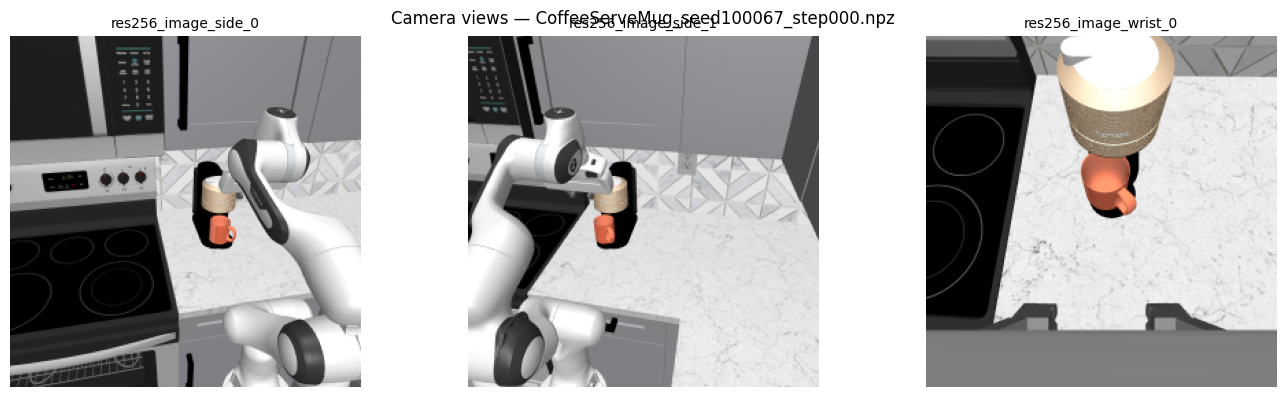

Backbone features: torch.Size([1, 295, 2048])

CHECKPOINT: BASE (no LoRA)   [CoffeeServeMug_seed100067_step000]


Across all timesteps:
  x: mean=1.8692, 	var=0.6568, 	std=0.6840, 	range=4.5563
  y: mean=0.6659, 	var=0.3782, 	std=0.5219, 	range=3.0471
  z: mean=1.4371, 	var=0.3776, 	std=0.5033, 	range=2.5919
Across final timestep only:
  x: mean=2.9970, 	var=1.2654, 	std=1.1249, 	range=7.6379
  y: mean=1.0979, 	var=0.7107, 	std=0.8430, 	range=5.1381
  z: mean=2.0165, 	var=0.8890, 	std=0.9428, 	range=4.7556
Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:
  x: mean=0.02919, 	var=5e-05, 	std=0.007071, 	range=0.03205
  y: mean=0.02336, 	var=4.621e-05, 	std=0.006798, 	range=0.03056
  z: mean=0.02101, 	var=1.521e-05, 	std=0.0039, 	range=0.02216
Jerk |3rd diff of EEF path|, final timestep only:
  x: mean=0.0196, 	var=0.0001954, 	std=0.01398, 	range=0.06299
  y: mean=0.02376, 	var=0.00033, 	std=0.01817, 	range=0.08789
  z: mean=0.01727, 	var=0.0002023, 	std=0.01422, 	range=0.0625
Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):
  x: mean=0.0874, 	var=0.000301

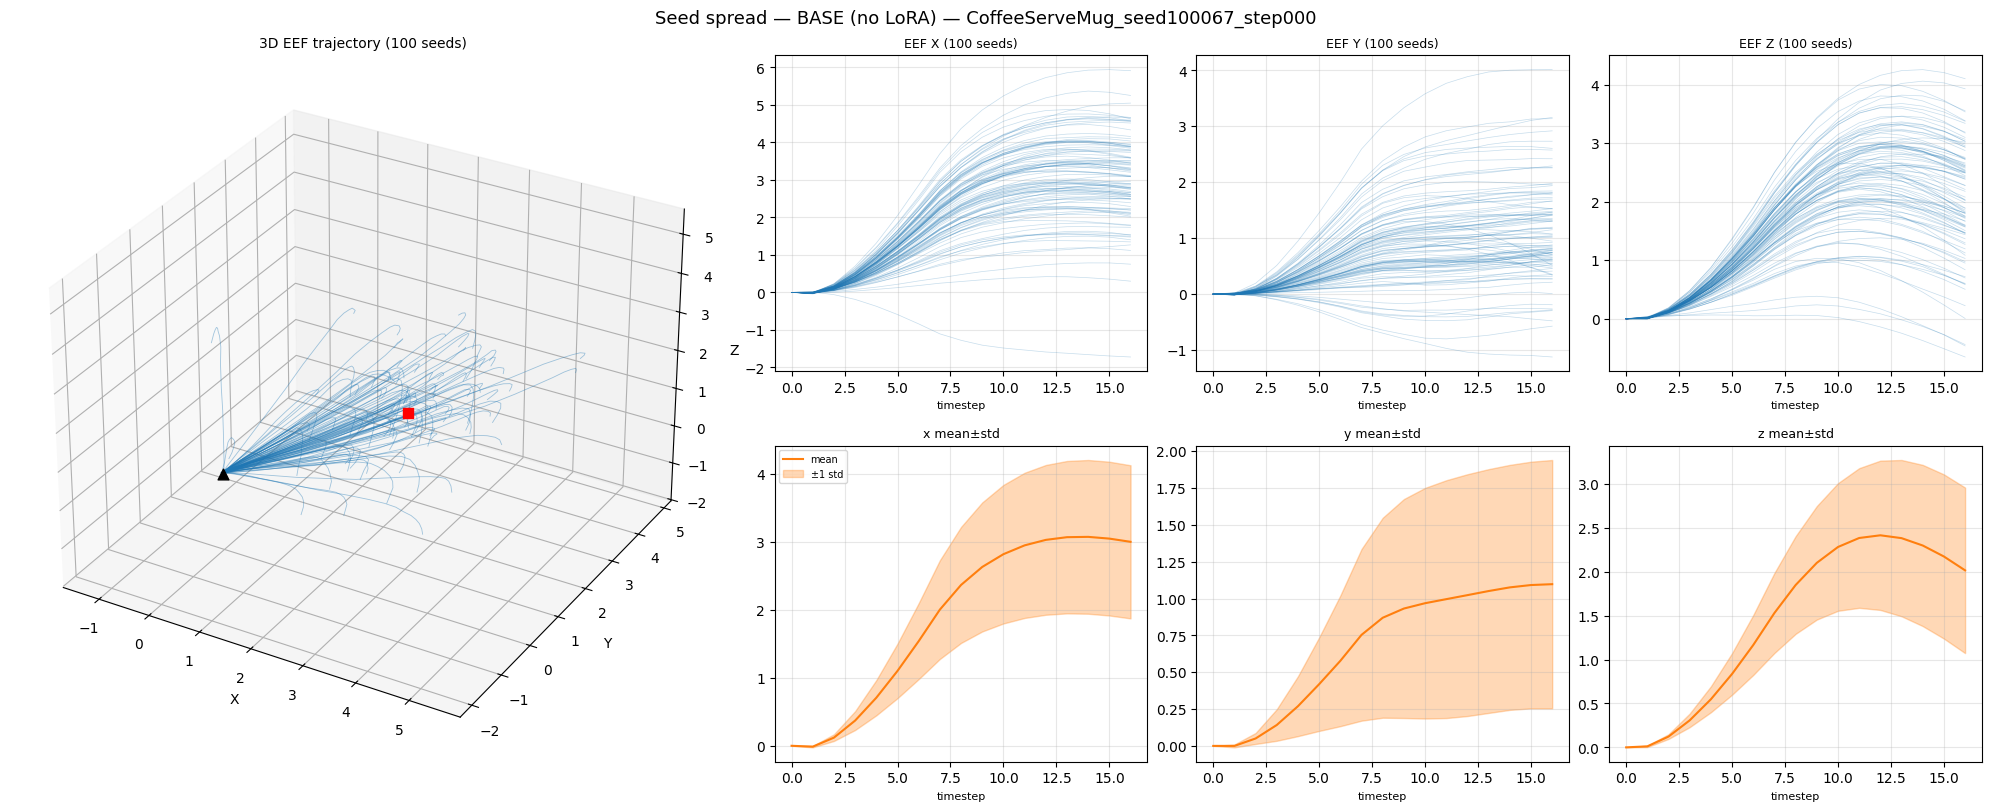


CHECKPOINT: PAWS1.5 it09   [CoffeeServeMug_seed100067_step000]


  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/full_pool4_v7/lr5e-5_plam0.4_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD0.9_3epoch_gs12_ng4_mb128_IAG0.3_postreopen1_res5_PAWS1.5/iter_0009


Across all timesteps:
  x: mean=1.7911, 	var=0.3363, 	std=0.4884, 	range=3.2354
  y: mean=0.6751, 	var=0.2373, 	std=0.4124, 	range=2.3748
  z: mean=1.2358, 	var=0.2365, 	std=0.3982, 	range=2.0412
Across final timestep only:
  x: mean=2.8511, 	var=0.6603, 	std=0.8126, 	range=5.4542
  y: mean=0.9912, 	var=0.4701, 	std=0.6857, 	range=4.1647
  z: mean=1.6477, 	var=0.5445, 	std=0.7379, 	range=3.6390
Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:
  x: mean=0.02944, 	var=3.326e-05, 	std=0.005767, 	range=0.02915
  y: mean=0.02452, 	var=4.842e-05, 	std=0.006959, 	range=0.03037
  z: mean=0.02111, 	var=1.487e-05, 	std=0.003856, 	range=0.0225
Jerk |3rd diff of EEF path|, final timestep only:
  x: mean=0.01799, 	var=0.0001634, 	std=0.01278, 	range=0.05835
  y: mean=0.02139, 	var=0.0002868, 	std=0.01693, 	range=0.07178
  z: mean=0.01236, 	var=0.0001095, 	std=0.01046, 	range=0.0498
Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):
  x: mean=0.09437, 	var

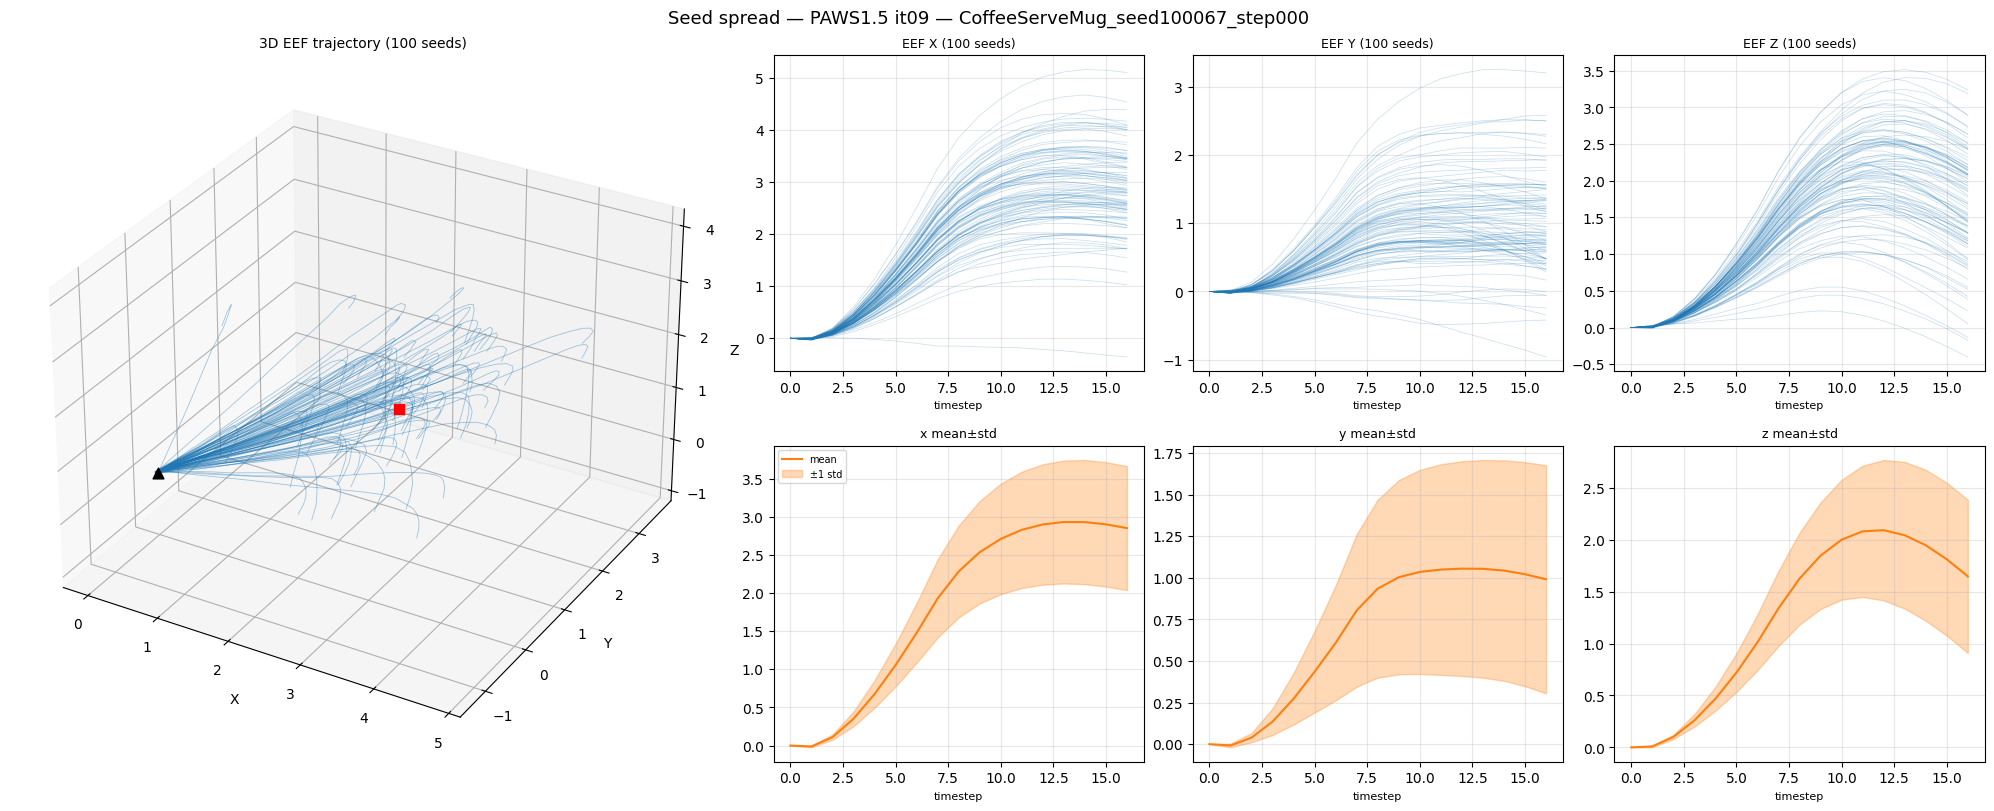

Plot data saved: /home/ubuntu/my_Isaac-GR00T/scripts/denoising_lab/notebooks/plot_data_v5.5/seed_spread__CoffeeServeMug_seed100067_step000.npz

##########################################################################################
SCENE 101067
##########################################################################################
Observation: /tmp/denoising_lab_seed_obs/CoffeeServeMug_seed101067_step000.npz
Task: ('pick the mug from under the coffee machine dispenser and place it on the counter',)
Plot data saved: /home/ubuntu/my_Isaac-GR00T/scripts/denoising_lab/notebooks/plot_data_v5.5/camera_views__CoffeeServeMug_seed101067_step000.npz


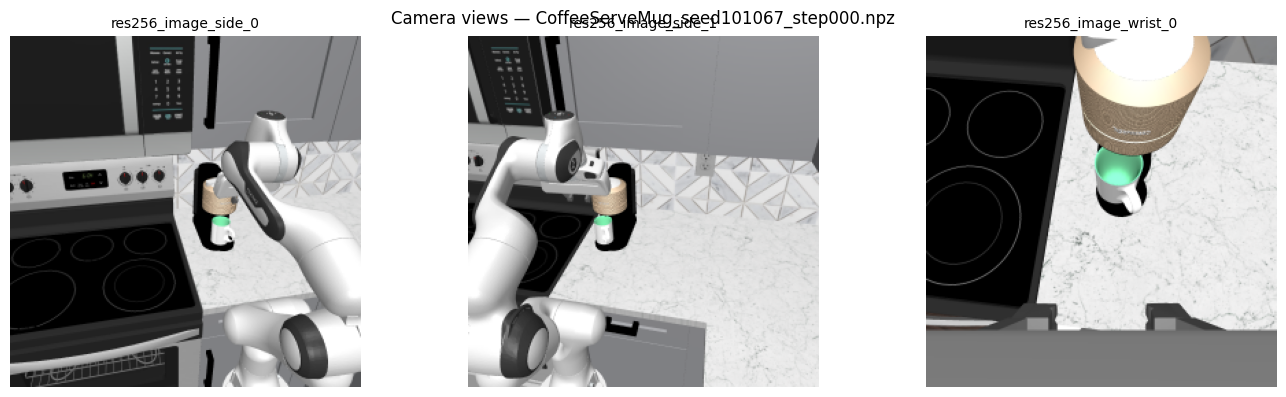

Backbone features: torch.Size([1, 295, 2048])

CHECKPOINT: BASE (no LoRA)   [CoffeeServeMug_seed101067_step000]


Across all timesteps:
  x: mean=2.0908, 	var=0.9253, 	std=0.8152, 	range=5.1600
  y: mean=0.0622, 	var=0.4216, 	std=0.5487, 	range=3.3530
  z: mean=1.1241, 	var=0.4775, 	std=0.5692, 	range=2.8717
Across final timestep only:
  x: mean=3.4051, 	var=1.7984, 	std=1.3410, 	range=8.6617
  y: mean=-0.1205, 	var=0.9037, 	std=0.9506, 	range=6.0034
  z: mean=1.5085, 	var=1.0941, 	std=1.0460, 	range=5.2822
Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:
  x: mean=0.03423, 	var=7.815e-05, 	std=0.00884, 	range=0.04262
  y: mean=0.0184, 	var=2.817e-05, 	std=0.005308, 	range=0.02509
  z: mean=0.01877, 	var=1.584e-05, 	std=0.00398, 	range=0.02271
Jerk |3rd diff of EEF path|, final timestep only:
  x: mean=0.01919, 	var=0.0002233, 	std=0.01494, 	range=0.06641
  y: mean=0.02369, 	var=0.0003468, 	std=0.01862, 	range=0.08545
  z: mean=0.01491, 	var=0.0001685, 	std=0.01298, 	range=0.05518
Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):
  x: mean=0.1045, 	var=

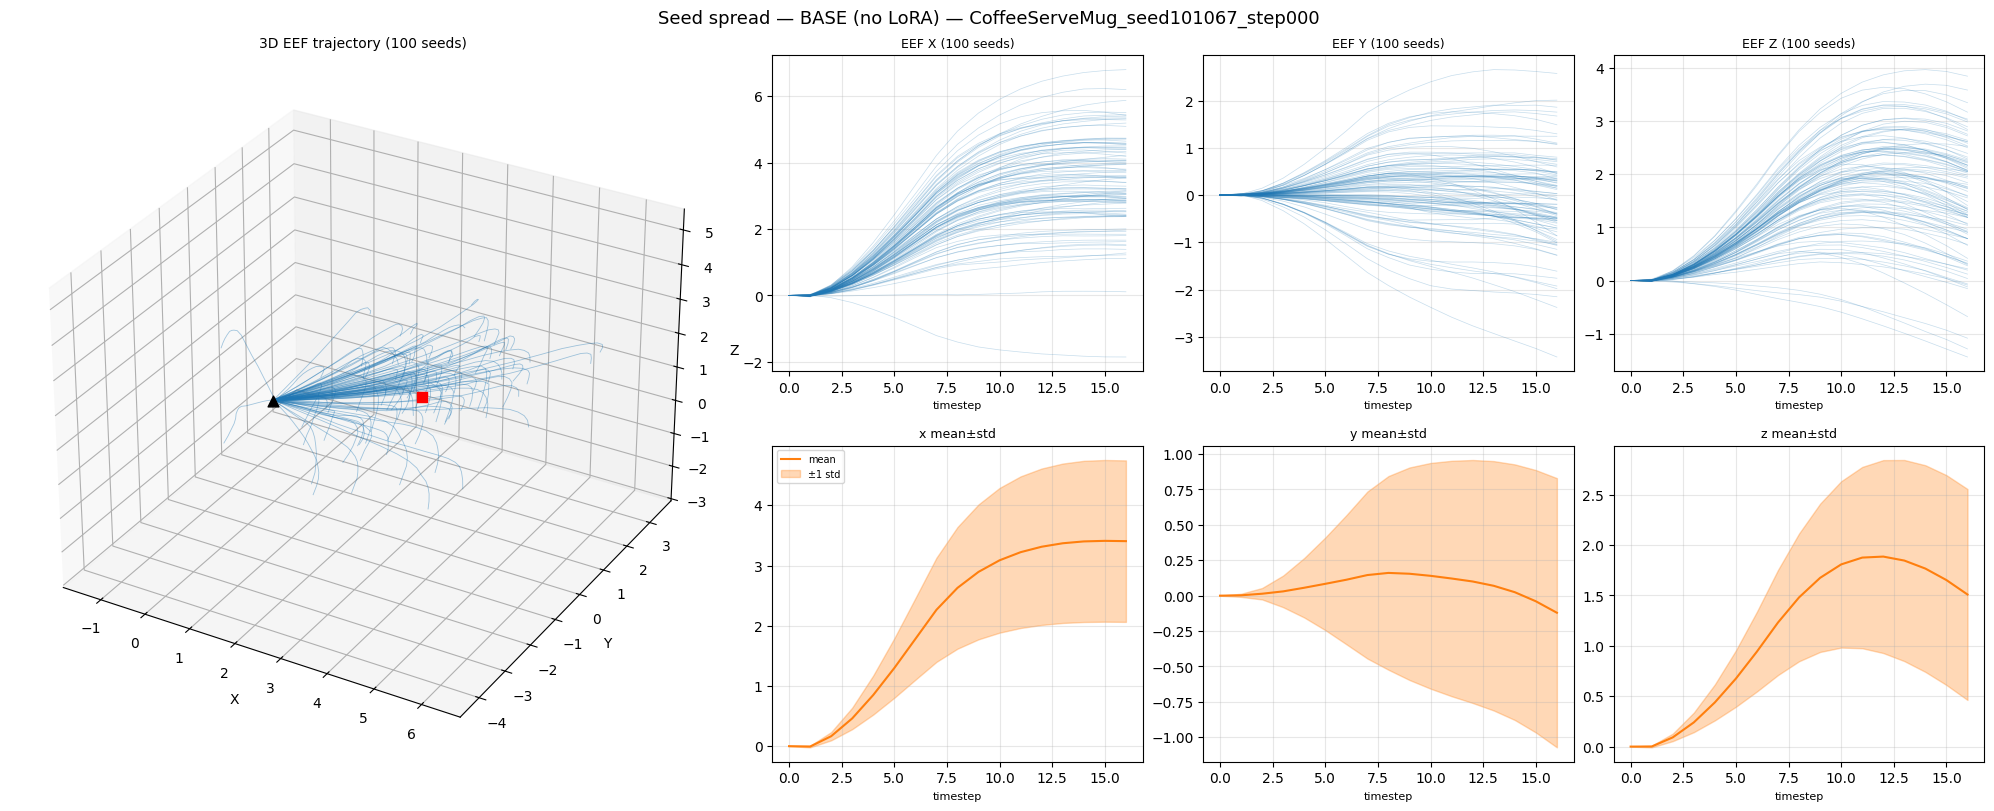


CHECKPOINT: PAWS1.5 it09   [CoffeeServeMug_seed101067_step000]
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/full_pool4_v7/lr5e-5_plam0.4_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD0.9_3epoch_gs12_ng4_mb128_IAG0.3_postreopen1_res5_PAWS1.5/iter_0009


Across all timesteps:
  x: mean=2.2986, 	var=0.4805, 	std=0.5849, 	range=3.7492
  y: mean=0.2063, 	var=0.2653, 	std=0.4334, 	range=2.6159
  z: mean=0.9483, 	var=0.3014, 	std=0.4514, 	range=2.4000
Across final timestep only:
  x: mean=3.7199, 	var=0.9734, 	std=0.9866, 	range=6.3942
  y: mean=-0.0385, 	var=0.5979, 	std=0.7733, 	range=4.8228
  z: mean=1.2066, 	var=0.6882, 	std=0.8296, 	range=4.3086
Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:
  x: mean=0.03685, 	var=4.551e-05, 	std=0.006746, 	range=0.03163
  y: mean=0.01955, 	var=2.76e-05, 	std=0.005254, 	range=0.02454
  z: mean=0.01888, 	var=1.635e-05, 	std=0.004044, 	range=0.02206
Jerk |3rd diff of EEF path|, final timestep only:
  x: mean=0.01479, 	var=0.0001355, 	std=0.01164, 	range=0.06543
  y: mean=0.01974, 	var=0.0002378, 	std=0.01542, 	range=0.07129
  z: mean=0.009039, 	var=5.399e-05, 	std=0.007348, 	range=0.03809
Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):
  x: mean=0.1082, 	

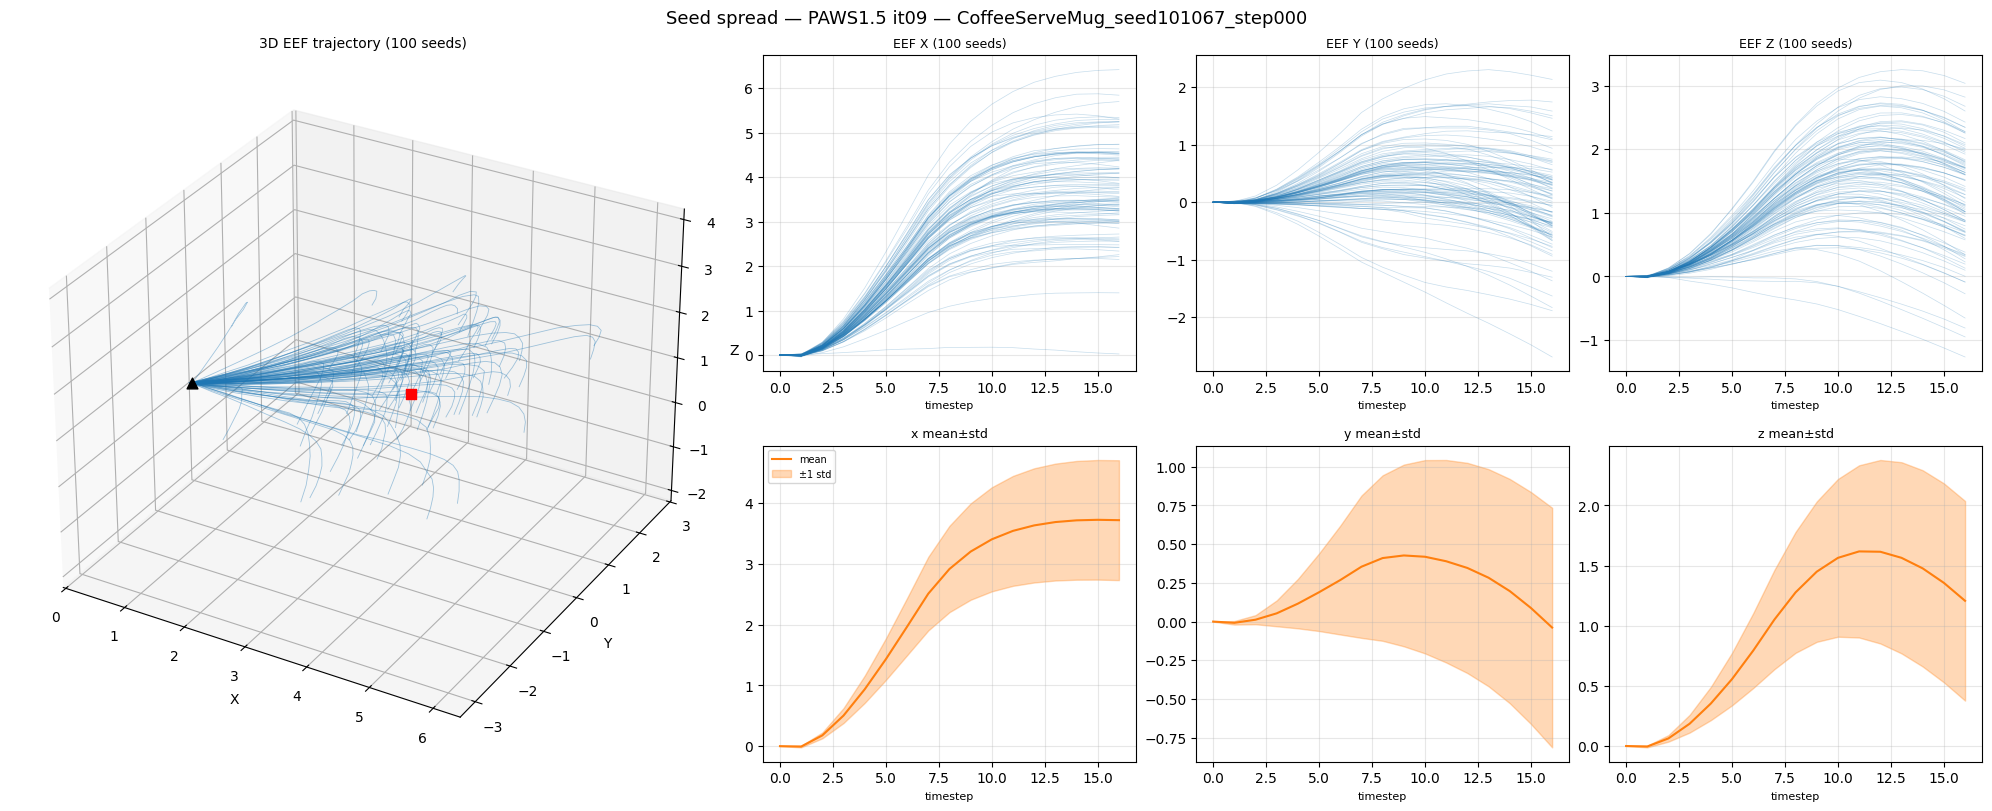

Plot data saved: /home/ubuntu/my_Isaac-GR00T/scripts/denoising_lab/notebooks/plot_data_v5.5/seed_spread__CoffeeServeMug_seed101067_step000.npz

##########################################################################################
SCENE 102067
##########################################################################################
Observation: /tmp/denoising_lab_seed_obs/CoffeeServeMug_seed102067_step000.npz
Task: ('pick the mug from under the coffee machine dispenser and place it on the counter',)
Plot data saved: /home/ubuntu/my_Isaac-GR00T/scripts/denoising_lab/notebooks/plot_data_v5.5/camera_views__CoffeeServeMug_seed102067_step000.npz


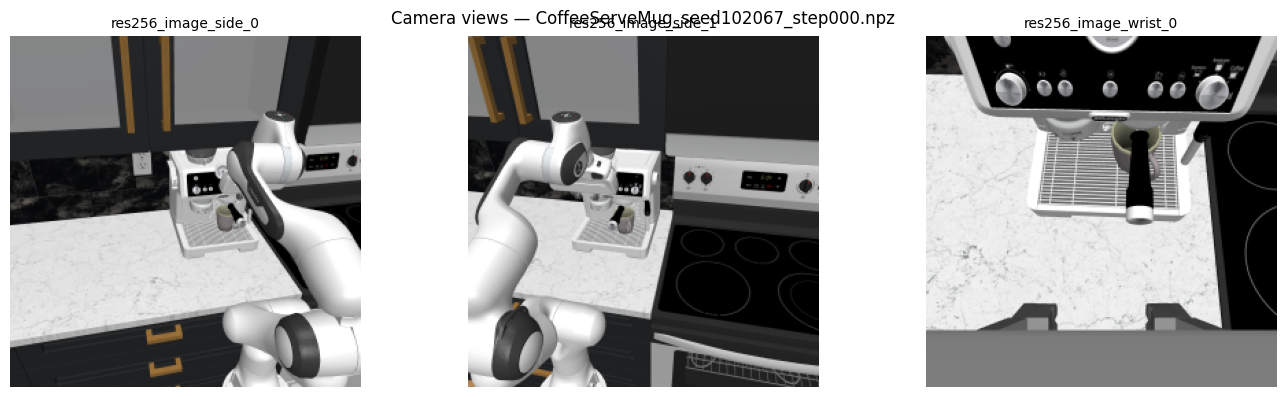

Backbone features: torch.Size([1, 295, 2048])

CHECKPOINT: BASE (no LoRA)   [CoffeeServeMug_seed102067_step000]


Across all timesteps:
  x: mean=2.2794, 	var=1.6897, 	std=1.1254, 	range=5.4874
  y: mean=0.5955, 	var=0.2391, 	std=0.4222, 	range=2.4392
  z: mean=0.3359, 	var=0.1229, 	std=0.2928, 	range=1.4991
Across final timestep only:
  x: mean=3.3143, 	var=2.9241, 	std=1.7100, 	range=8.7648
  y: mean=0.8740, 	var=0.4901, 	std=0.7000, 	range=4.2427
  z: mean=0.3141, 	var=0.3080, 	std=0.5550, 	range=3.0540
Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:
  x: mean=0.03572, 	var=0.0001444, 	std=0.01202, 	range=0.05117
  y: mean=0.01841, 	var=2.254e-05, 	std=0.004748, 	range=0.02264
  z: mean=0.01369, 	var=9.033e-06, 	std=0.003005, 	range=0.01632
Jerk |3rd diff of EEF path|, final timestep only:
  x: mean=0.02282, 	var=0.000332, 	std=0.01822, 	range=0.09131
  y: mean=0.01989, 	var=0.0002566, 	std=0.01602, 	range=0.07135
  z: mean=0.01557, 	var=0.0002009, 	std=0.01417, 	range=0.06006
Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):
  x: mean=0.1165, 	var=

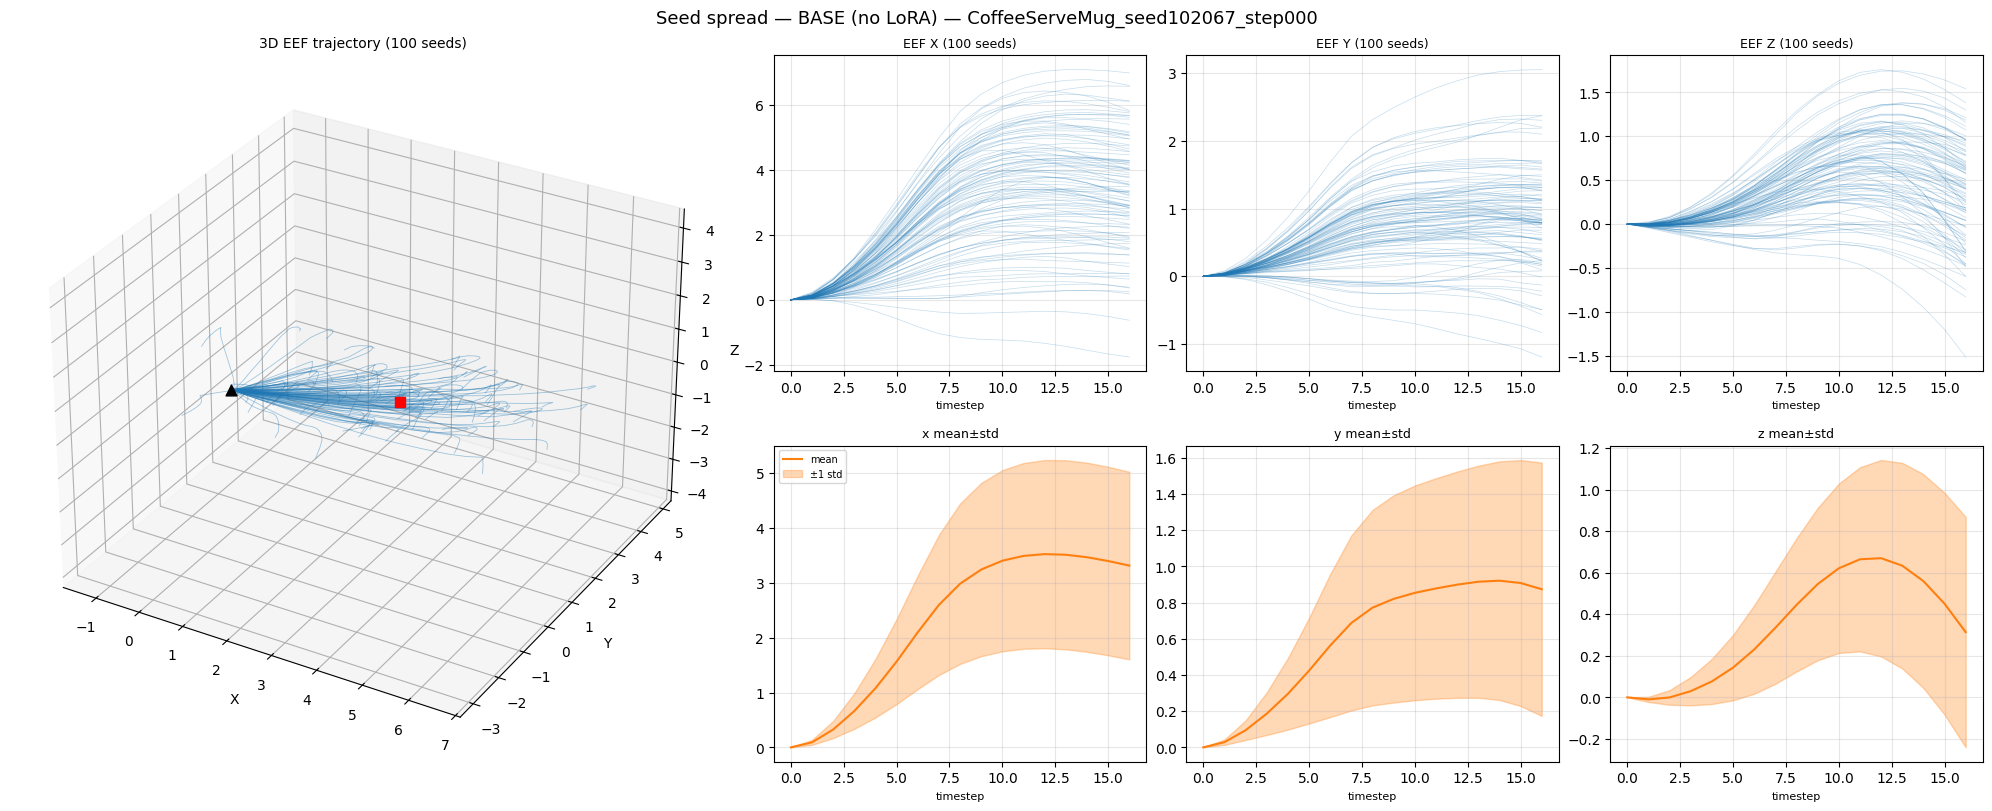


CHECKPOINT: PAWS1.5 it09   [CoffeeServeMug_seed102067_step000]
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/full_pool4_v7/lr5e-5_plam0.4_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD0.9_3epoch_gs12_ng4_mb128_IAG0.3_postreopen1_res5_PAWS1.5/iter_0009


Across all timesteps:
  x: mean=2.2885, 	var=1.0609, 	std=0.8892, 	range=4.7760
  y: mean=0.5579, 	var=0.1354, 	std=0.3170, 	range=1.6954
  z: mean=0.2660, 	var=0.0592, 	std=0.2048, 	range=1.0171
Across final timestep only:
  x: mean=3.3448, 	var=1.8872, 	std=1.3738, 	range=7.7345
  y: mean=0.7633, 	var=0.2794, 	std=0.5286, 	range=2.9668
  z: mean=0.3007, 	var=0.1284, 	std=0.3583, 	range=1.7761
Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:
  x: mean=0.03652, 	var=9.306e-05, 	std=0.009647, 	range=0.04611
  y: mean=0.01947, 	var=2.329e-05, 	std=0.004826, 	range=0.02673
  z: mean=0.01586, 	var=1.498e-05, 	std=0.003871, 	range=0.01901
Jerk |3rd diff of EEF path|, final timestep only:
  x: mean=0.02179, 	var=0.0002935, 	std=0.01713, 	range=0.07959
  y: mean=0.01859, 	var=0.0002482, 	std=0.01576, 	range=0.08057
  z: mean=0.01246, 	var=0.0001235, 	std=0.01111, 	range=0.05322
Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):
  x: mean=0.1224, 	va

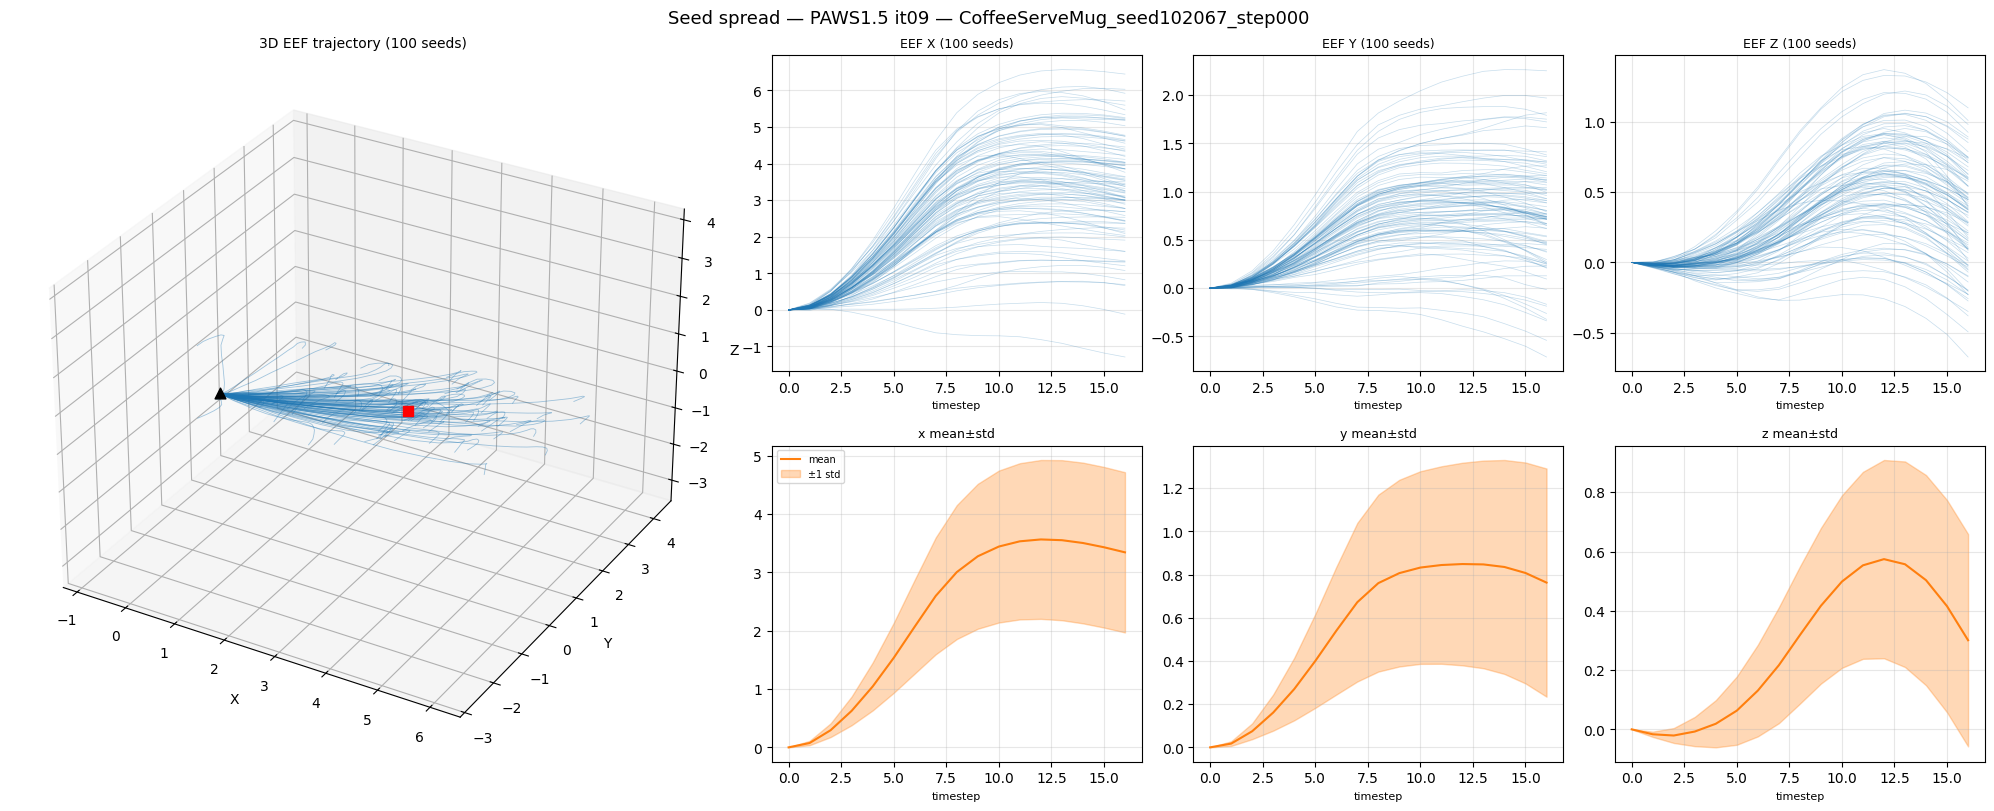

Plot data saved: /home/ubuntu/my_Isaac-GR00T/scripts/denoising_lab/notebooks/plot_data_v5.5/seed_spread__CoffeeServeMug_seed102067_step000.npz

##########################################################################################
SCENE 103067
##########################################################################################
Observation: /tmp/denoising_lab_seed_obs/CoffeeServeMug_seed103067_step000.npz
Task: ('pick the mug from under the coffee machine dispenser and place it on the counter',)
Plot data saved: /home/ubuntu/my_Isaac-GR00T/scripts/denoising_lab/notebooks/plot_data_v5.5/camera_views__CoffeeServeMug_seed103067_step000.npz


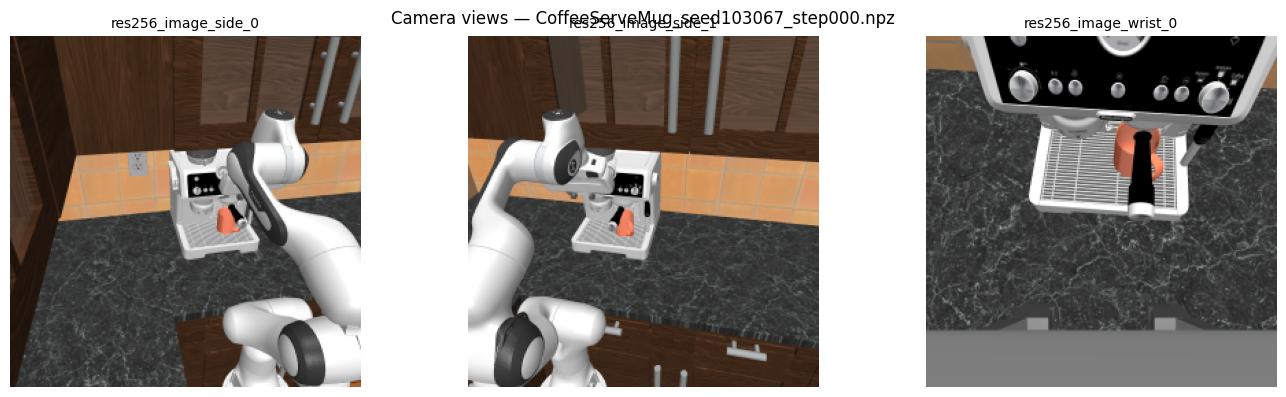

Backbone features: torch.Size([1, 295, 2048])

CHECKPOINT: BASE (no LoRA)   [CoffeeServeMug_seed103067_step000]


Across all timesteps:
  x: mean=0.8373, 	var=1.0843, 	std=0.8873, 	range=4.5232
  y: mean=-0.0879, 	var=0.3041, 	std=0.4692, 	range=2.8244
  z: mean=0.1297, 	var=0.2440, 	std=0.4039, 	range=2.1233
Across final timestep only:
  x: mean=1.2370, 	var=1.7921, 	std=1.3387, 	range=7.2683
  y: mean=-0.2396, 	var=0.5946, 	std=0.7711, 	range=4.8899
  z: mean=-0.2656, 	var=0.6841, 	std=0.8271, 	range=4.6833
Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:
  x: mean=0.02521, 	var=6.596e-05, 	std=0.008122, 	range=0.04378
  y: mean=0.01822, 	var=2.74e-05, 	std=0.005234, 	range=0.0245
  z: mean=0.01408, 	var=9.558e-06, 	std=0.003092, 	range=0.01562
Jerk |3rd diff of EEF path|, final timestep only:
  x: mean=0.02393, 	var=0.000413, 	std=0.02032, 	range=0.1172
  y: mean=0.02292, 	var=0.0003312, 	std=0.0182, 	range=0.07617
  z: mean=0.01752, 	var=0.0002469, 	std=0.01571, 	range=0.07031
Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):
  x: mean=0.1392, 	var=

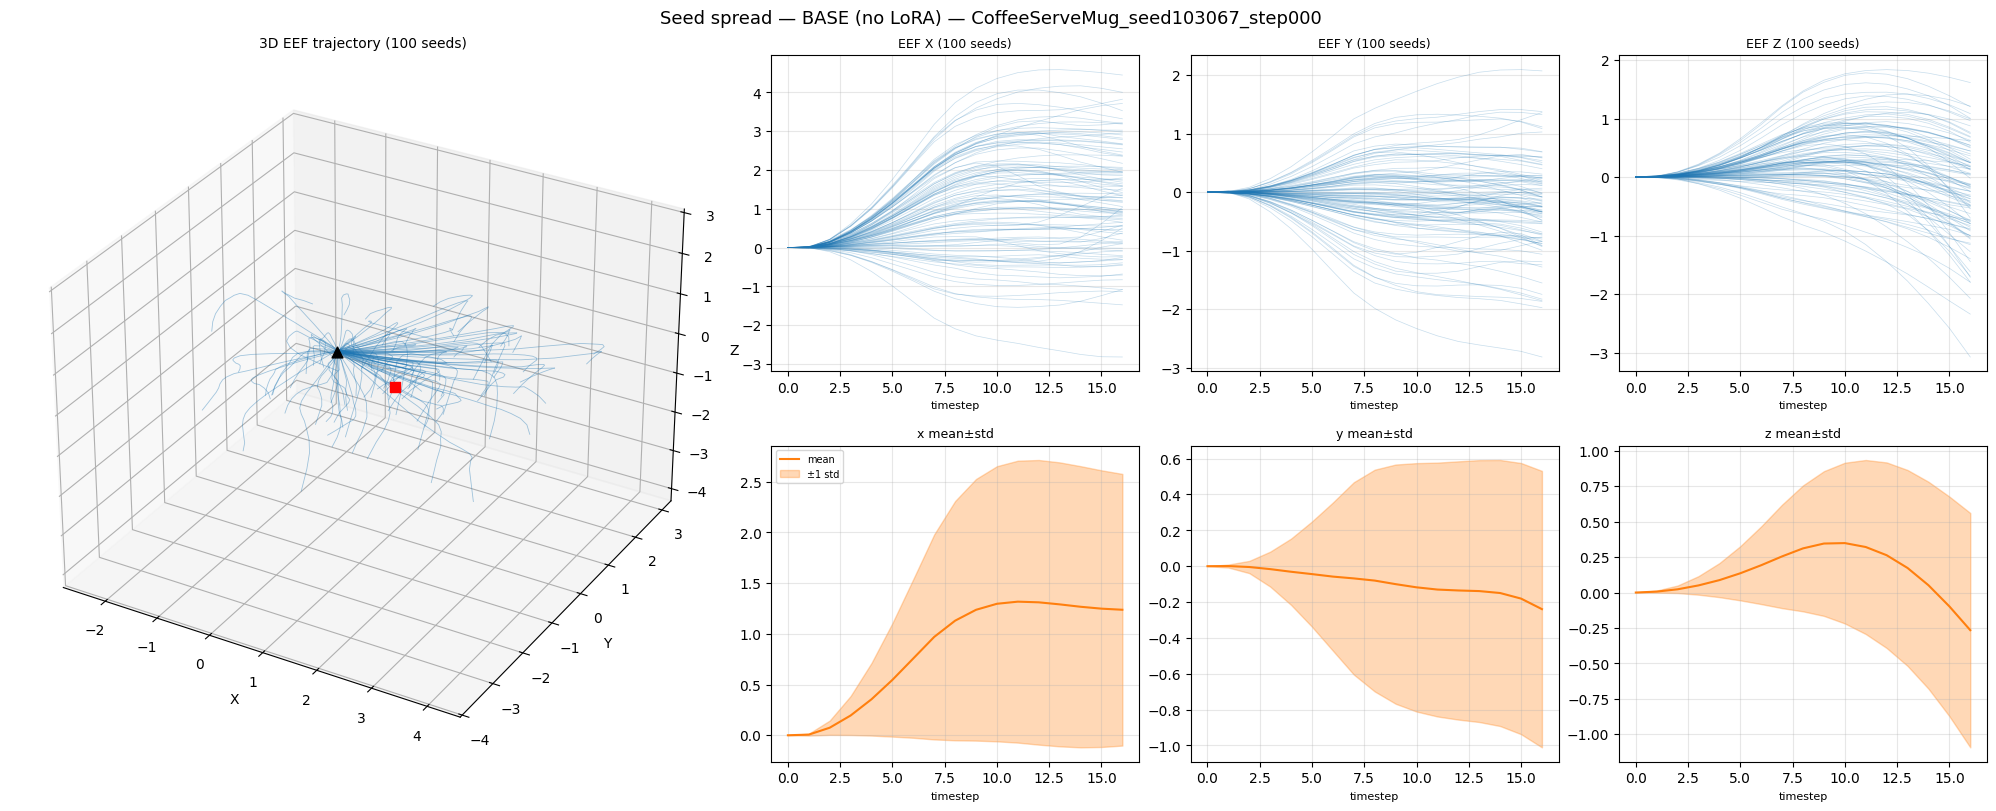


CHECKPOINT: PAWS1.5 it09   [CoffeeServeMug_seed103067_step000]
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/full_pool4_v7/lr5e-5_plam0.4_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD0.9_3epoch_gs12_ng4_mb128_IAG0.3_postreopen1_res5_PAWS1.5/iter_0009


Across all timesteps:
  x: mean=1.0326, 	var=0.6514, 	std=0.6849, 	range=3.7276
  y: mean=-0.0595, 	var=0.1686, 	std=0.3485, 	range=2.0082
  z: mean=0.1292, 	var=0.1296, 	std=0.2964, 	range=1.5316
Across final timestep only:
  x: mean=1.4961, 	var=1.1041, 	std=1.0508, 	range=5.9731
  y: mean=-0.2645, 	var=0.3265, 	std=0.5714, 	range=3.4561
  z: mean=-0.1653, 	var=0.3169, 	std=0.5630, 	range=3.0562
Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:
  x: mean=0.02694, 	var=5.107e-05, 	std=0.007147, 	range=0.03932
  y: mean=0.01814, 	var=2.309e-05, 	std=0.004805, 	range=0.02476
  z: mean=0.01461, 	var=1.138e-05, 	std=0.003373, 	range=0.01829
Jerk |3rd diff of EEF path|, final timestep only:
  x: mean=0.02203, 	var=0.0003492, 	std=0.01869, 	range=0.1172
  y: mean=0.01933, 	var=0.0002583, 	std=0.01607, 	range=0.07129
  z: mean=0.01223, 	var=0.0001182, 	std=0.01087, 	range=0.04785
Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):
  x: mean=0.1488, 	

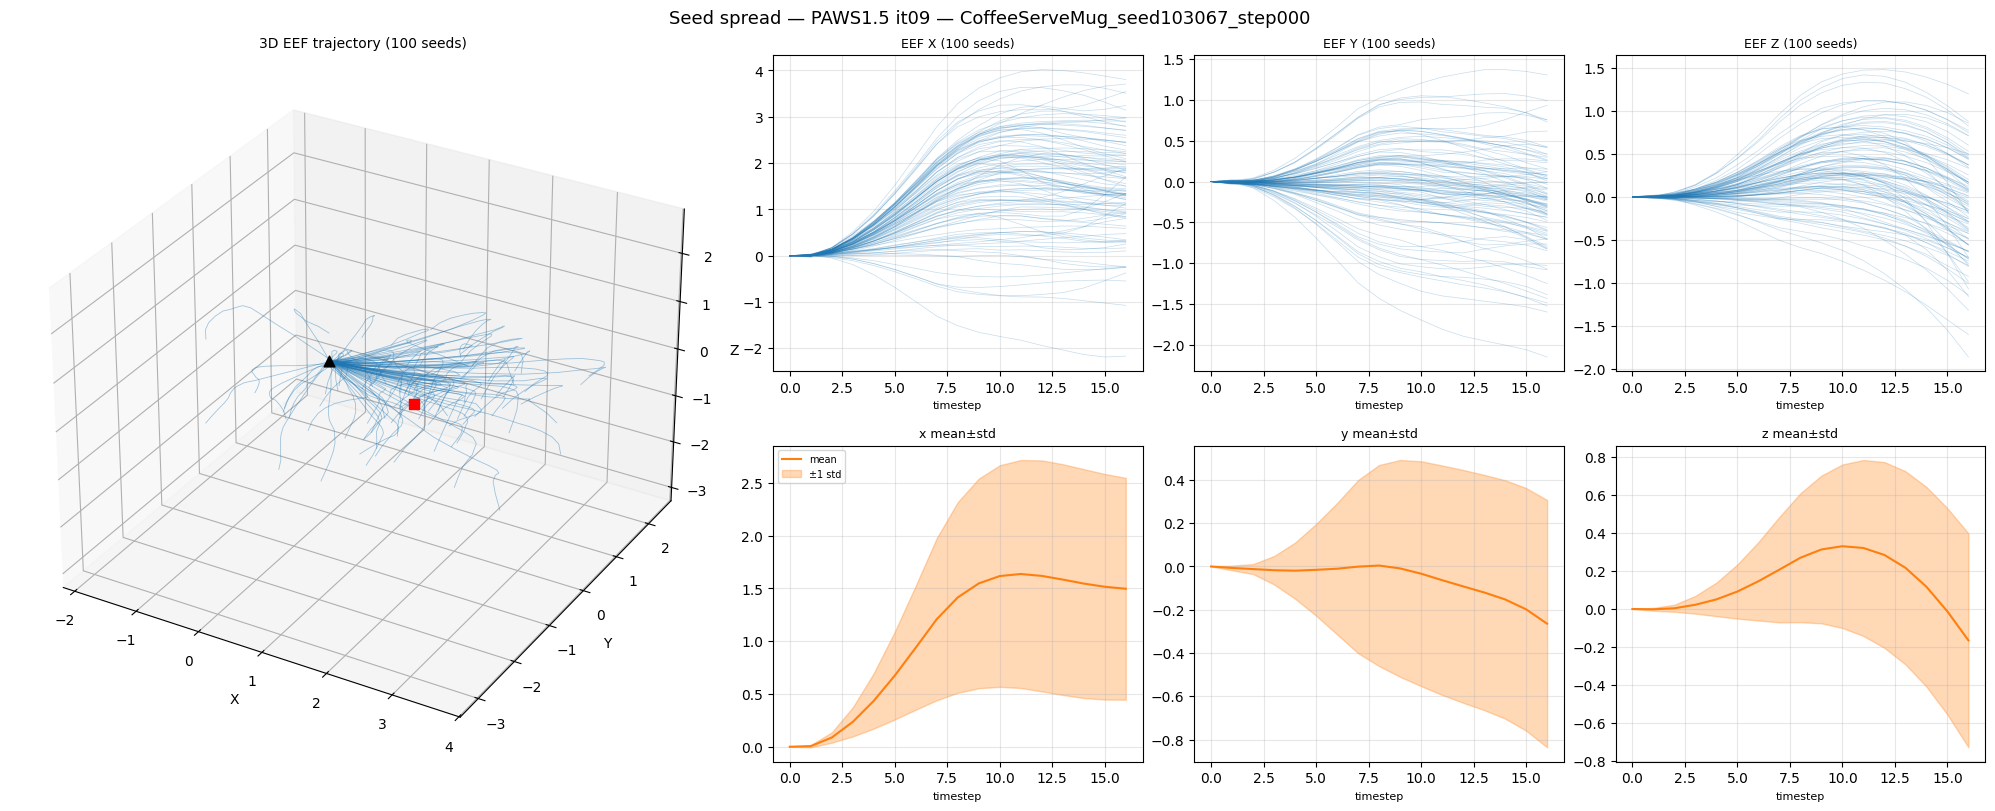

Plot data saved: /home/ubuntu/my_Isaac-GR00T/scripts/denoising_lab/notebooks/plot_data_v5.5/seed_spread__CoffeeServeMug_seed103067_step000.npz


In [7]:
# Cell 5: Run the comparison (base model + every checkpoint) on each pool scene's first
# observation (Cell 1.5). Re-run one scene with analyze_all_checkpoints(OBS_PATHS[seed]).
results_by_seed = {}
for _seed in SEEDS:
    print("\n" + "#" * 90)
    print(f"SCENE {_seed}")
    print("#" * 90)
    _, results_by_seed[_seed] = analyze_all_checkpoints(OBS_PATHS[_seed])


## Cross-scene summary

One table per scene, then each run's ratio to BASE averaged over the scenes, then one figure
with the scenes side by side. Everything is read back from the saved `seed_spread` files, so
this cell needs no GPU and can be re-run offline.

- `std x/y/z`: final-timestep EEF std across seeds. Higher = more noise-driven action
  diversity; lower = the run is more decisive for this observation.
- `pathjerk`: `sum ‖jerk‖ / path length`, scale-free. `x base` is the ratio to BASE in the
  same scene.
- `|jerk|/step` and `path len`: raw jerk and path length, to tell "rougher" from "bigger".
- `abs leak` (v4.5): the step-to-step part (rfft bins 3+ along the 16 steps) of each seed's
  raw normalized EEF action, regressed on the same part of its own initial noise, i.e. the
  fraction of the noise that passes straight through. On the overfit observation v4.5 read
  0.0083 for BASE and 0.013–0.016 for the jitter-fix checkpoints. `noise corr` near 1 means
  the wiggle is that noise, step for step.

The cell raises if the initial noise differs across runs, because then no leak measure is valid.



scene 100067  (CoffeeServeMug_seed100067_step000)
  run                 std x  std y  std z pathjerk x base |jerk|/step path len abs leak x base noise corr
  BASE (no LoRA)      1.125  0.843  0.943    0.146  1.00x      0.0245     4.74   0.0050  1.00x       0.41
  PAWS1.5 it09        0.813  0.686  0.738    0.159  1.09x      0.0250     4.43   0.0038  0.75x       0.31

scene 101067  (CoffeeServeMug_seed101067_step000)
  run                 std x  std y  std z pathjerk x base |jerk|/step path len abs leak x base noise corr
  BASE (no LoRA)      1.341  0.951  1.046    0.153  1.00x      0.0238     4.64   0.0057  1.00x       0.44
  PAWS1.5 it09        0.987  0.773  0.830    0.153  1.00x      0.0251     4.82   0.0033  0.58x       0.26

scene 102067  (CoffeeServeMug_seed102067_step000)
  run                 std x  std y  std z pathjerk x base |jerk|/step path len abs leak x base noise corr
  BASE (no LoRA)      1.710  0.700  0.555    0.165  1.00x      0.0226     4.44   0.0061  1.00x       0.42

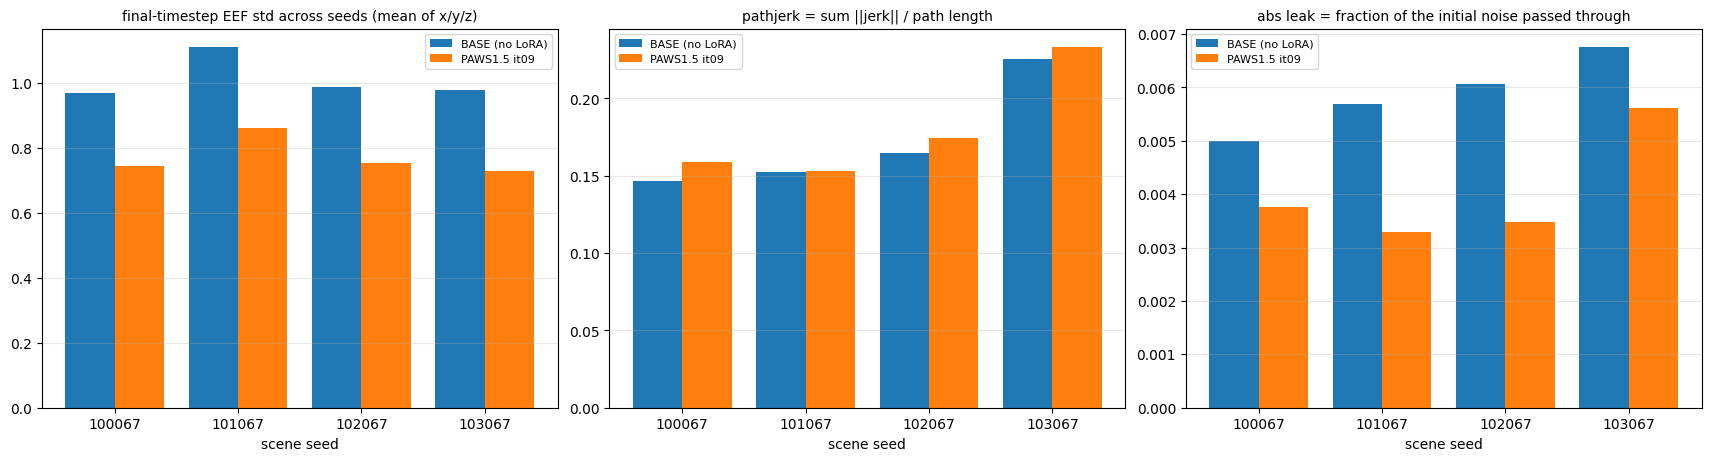

In [8]:
# Cell 6: Cross-scene summary, read back from the seed_spread files (no GPU).
def _hp(d):
    """Step-to-step part of (n_seeds, T, 3) arrays: remove the seed mean, drop rfft bins 0-2."""
    f = np.fft.rfft(d - d.mean(axis=0), axis=1)
    f[:, :3] = 0
    return np.fft.irfft(f, n=d.shape[1], axis=1)


def _seed_corr(A, B):
    """Mean over seeds of the correlation between A[s] and B[s]."""
    return float(np.mean([np.corrcoef(a, b)[0, 1]
                          for a, b in zip(A.reshape(len(A), -1), B.reshape(len(B), -1))]))


def scene_summary(seeds=SEEDS):
    task = ENV_NAME.split("/")[-1].removesuffix("_PandaOmron_Env")
    out, runs_of = {}, {}
    for seed in seeds:
        tag = f"{task}_seed{seed}_step000"
        z = np.load(os.path.join(PLOT_DATA_DIR, f"seed_spread__{tag}.npz"))
        runs = runs_of[seed] = [str(r) for r in z["runs"]]
        if not all(np.array_equal(z["noise"][r], z["noise"][0]) for r in range(len(runs))):
            raise RuntimeError(f"{tag}: initial noise differs across runs, so seeds are not "
                               f"shared and no leak measure is valid")
        he = _hp(z["noise"][0])
        print(f"\nscene {seed}  ({tag})")
        print(f"  {'run':18s} {'std x':>6s} {'std y':>6s} {'std z':>6s} {'pathjerk':>8s} {'x base':>6s} "
              f"{'|jerk|/step':>11s} {'path len':>8s} {'abs leak':>8s} {'x base':>6s} {'noise corr':>10s}")
        for r, run in enumerate(runs):
            pos = z["all_pos"][r]
            D, j = np.diff(pos, axis=1), np.diff(pos, n=3, axis=1)
            L = np.linalg.norm(D, axis=2).sum(axis=1)
            h = _hp(z["act_norm"][r])
            v = out[(seed, run)] = {
                "end_std": pos[:, -1].std(axis=0),
                "pathjerk": float((np.linalg.norm(j, axis=2).sum(axis=1) / np.maximum(L, 1e-9)).mean()),
                "jerk_step": float(np.abs(j).mean()),
                "path_len": float(L.mean()),
                "abs_leak": float((h * he).sum() / (he * he).sum()),
                "noise_corr": _seed_corr(h, he),
            }
            b = out[(seed, runs[0])]                               # first run is BASE
            print(f"  {run:18s} {v['end_std'][0]:6.3f} {v['end_std'][1]:6.3f} {v['end_std'][2]:6.3f} "
                  f"{v['pathjerk']:8.3f} {v['pathjerk'] / b['pathjerk']:5.2f}x {v['jerk_step']:11.4f} "
                  f"{v['path_len']:8.2f} {v['abs_leak']:8.4f} {v['abs_leak'] / b['abs_leak']:5.2f}x "
                  f"{v['noise_corr']:10.2f}")

    # Per-scene ratio to BASE, averaged over scenes (runs present in every scene).
    runs = [r for r in runs_of[seeds[0]] if all(r in runs_of[s] for s in seeds)]
    ratio = lambda run, k: np.mean([np.mean(out[(s, run)][k]) / np.mean(out[(s, runs[0])][k])
                                    for s in seeds])
    print(f"\nratio to {runs[0]}, mean over the {len(seeds)} scenes:")
    print(f"  {'run':18s} {'end std':>8s} {'pathjerk':>8s} {'|jerk|/step':>11s} {'path len':>8s} {'abs leak':>8s}")
    for run in runs[1:]:
        print(f"  {run:18s} {ratio(run, 'end_std'):7.2f}x {ratio(run, 'pathjerk'):7.2f}x "
              f"{ratio(run, 'jerk_step'):10.2f}x {ratio(run, 'path_len'):7.2f}x {ratio(run, 'abs_leak'):7.2f}x")

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), constrained_layout=True)
    x, w = np.arange(len(seeds)), 0.8 / len(runs)
    for ax, (k, ttl) in zip(axes, [("end_std", "final-timestep EEF std across seeds (mean of x/y/z)"),
                                   ("pathjerk", "pathjerk = sum ||jerk|| / path length"),
                                   ("abs_leak", "abs leak = fraction of the initial noise passed through")]):
        for i, run in enumerate(runs):
            ax.bar(x + (i - (len(runs) - 1) / 2) * w, [np.mean(out[(s, run)][k]) for s in seeds], w, label=run)
        ax.set_xticks(x)
        ax.set_xticklabels([str(s) for s in seeds])
        ax.set_xlabel("scene seed")
        ax.set_title(ttl, fontsize=10)
        ax.grid(True, axis="y", alpha=0.3)
        ax.legend(fontsize=8)
    plt.show()
    return out


summary = scene_summary()
